<a href="https://colab.research.google.com/github/DoshikEnergo/Power-transformer-data-for-fault-diagnosis/blob/main/Power_Transformer_Data_For_Fault_Diagnosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Power Transformer Data For Fault Diagnosis

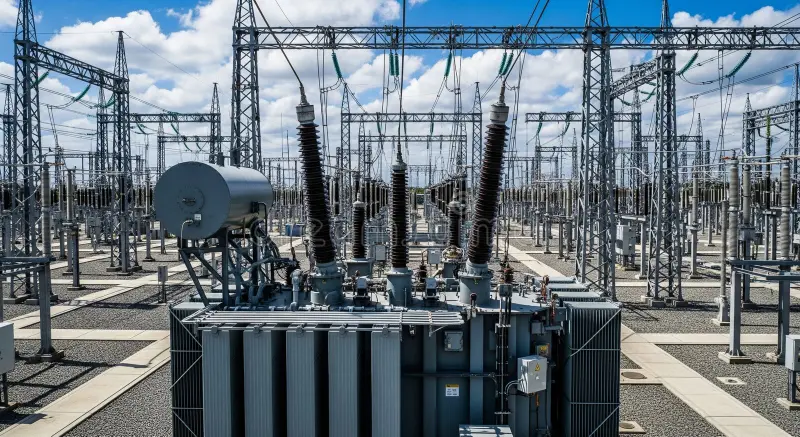

[Data Set](https://ieee-dataport.org/documents/dissolved-gas-data-transformer-oil-fault-diagnosis-power-transformers-membership-degree)

Power transformers are essential machines in every electricity generation and distribution grid. Its reliability must be assured as an unexpected failure might represent a catastrophic event leading to a lack of the electricity ser- vice in a whole community or region. Given the importance of such trans-formers, predictive maintenance techniques have been increasingly used to detect incipient faults and trigger maintenance actions accurately when are needed. One of the traditional analyses on power transformers is on oil gas analysis. Multiple methods have been proposed to detect and identify faults on different variables extracted from the oil gas analysis. However, these traditional techniques not always offer a conclusive diagnostic. Given the in- creasing use of data-driven models in fault diagnosis, this study was focused to collect and organize a data from oil gas analysis preformed on real transformers over multiple years of service.

## Dissolved Gas Analysis (DGA)

## Import Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Power transformer data for fault diagnosis/dga_dataset.csv", sep = ";")

In [ ]:
data.head(10)

,H2,CH4,C2H6,C2H4,C2H2,Fail
0,345,"112,3","27,5","51,5","58,8",D1
1,181,262,41,28,"0,001",T1
2,"172,9",334,172,"812,5","37,7",T3
3,127,107,11,154,224,D2
4,60,40,"6,9",110,70,D2
5,220,340,42,480,14,T3
6,170,320,53,520,"3,2",T3
7,27,90,42,73,"0,2",T1
8,565,53,34,47,"0,001",D1
9,56,286,96,28,7,T3


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4150 entries, 0 to 4149
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   H2      4150 non-null   object
 1   CH4     4150 non-null   object
 2   C2H6    4150 non-null   object
 3   C2H4    4150 non-null   object
 4   C2H2    4150 non-null   object
 5   Fail    4150 non-null   object
dtypes: object(6)
memory usage: 194.7+ KB


In [ ]:
data.columns

Index(['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2', 'Fail'], dtype='object')

In [ ]:
gase = ['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2']
data['Fail'].unique()

array(['D1', 'T1', 'T3', 'D2', 'T2', 'PD', '      T3', '      T2',
       '     T3', '     T2', '    T3', '    T2', '   T2', '           T1',
       '           T2', '          T1', '         T1', '         PD',
       '             T3', '            T3', '      T1', '         T2',
       '        T2', '       T2', '        T3', '        T1',
       '         T3', '       T3', '       T1', '     T1', 'NF'],
      dtype=object)

In [ ]:
for i in data['Fail']:
  if 'D1' in i:
    data['Fail'] = data['Fail'].replace(i, 'D1')
  elif 'D2' in i:
    data['Fail'] = data['Fail'].replace(i, 'D2')
  elif 'T1' in i:
    data['Fail'] = data['Fail'].replace(i, 'T1')
  elif 'T2' in i:
    data['Fail'] = data['Fail'].replace(i, 'T2')
  elif 'T3' in i:
    data['Fail'] = data['Fail'].replace(i, 'T3')
  elif 'PD' in i:
    data['Fail'] = data['Fail'].replace(i, 'PD')
  elif 'NF' in i:
    data['Fail'] = data['Fail'].replace(i, 'NF')

In [ ]:
data['Fail'].unique()

array(['D1', 'T1', 'T3', 'D2', 'T2', 'PD', 'NF'], dtype=object)

# Column Breakdown for Dissolved Gas Analysis (DGA) Dataset

This dataset contains **6 columns** focused purely on Dissolved Gas Analysis (DGA) parameters and categorical fault classification. It is designed for multi-class classification tasks to identify specific failure modes in oil-immersed power transformers.

---

## 1. Input Features (Dissolved Gases in ppm)
These 5 gases are key indicators of oil degradation caused by electrical and thermal stresses within the transformer tank.

| Column Name | Gas Name & Formula | Physical Meaning & Diagnostic Role |
| :--- | :--- | :--- |
| **`H2`** | Hydrogen ($H_2$) | Primary indicator of **low-energy electrical faults**, such as partial discharges (PD) and corona activity. |
| **`CH4`** | Methane ($CH_4$) | Marker for **low-to-medium temperature thermal faults** ($150–300^\circ\text{C}$). Indicates local hot spots in joints or core laminations. |
| **`C2H6`** | Ethane ($C_2H_6$) | Companion gas for **mild thermal decomposition** of transformer oil ($200–300^\circ\text{C}$). Typically analyzed alongside methane. |
| **`C2H4`** | Ethylene ($C_2H_4$) | Key indicator of **high-temperature thermal faults** (above $300^\circ\text{C}$), such as severe contact overheating or magnetic circuit faults. |
| **`C2H2`** | Acetylene ($C_2H_2$) | **The most critical gas**. It only forms under extreme temperatures (above $700^\circ\text{C}$), explicitly signaling **arcing**, heavy sparking, or full insulation breakdown. |

---

## Target Labels Breakdown (IEC 60599 Standard)

The `Fail` column represents the classification of transformer conditions based on the **IEC 60599 international standard**. Below is the physical interpretation of each unique label found in the dataset:

| Label | Full Name | Physical Meaning & Temperature Range | Typical Root Causes |
| :--- | :--- | :--- | :--- |
| **`NF`** | **No Fault** | Normal operation. Gas concentrations are within acceptable baseline limits. | Healthy transformer, normal aging. |
| **`PD`** | **Partial Discharge** | Low-energy electrical discharges occurring in gas bubbles or voids within the insulation. | Incomplete impregnation, moisture in paper, cavities in solid insulation. |
| **`D1`** | **Discharges of Low Energy** | Sparking or low-energy arcing. Clear evidence of carbonized particles in the oil. | Sparking between loose contacts, tracking in wood blocks, selector switch breaking. |
| **`D2`** | **Discharges of High Energy** | High-energy **electrical arcing**. Severe breakdown of fluid or solid insulation. | Short-circuit flashover, power arcing, winding-to-winding or winding-to-ground пробой. |
| **`T1`** | **Thermal Fault < 300°C** | Low-temperature thermal overheating. General insulation coloring changes (turns brown). | Localized overheating of connections, overloaded transformer, stray eddy currents. |
| **`T2`** | **Thermal Fault 300°C – 700°C** | Medium-temperature thermal overheating. Carbonization of paper insulation begins. | Poor contact joints (bolted/welded), bad connections on lead leads, OLTC contacts overheating. |
| **`T3`** | **Thermal Fault > 700°C** | High-temperature thermal overheating. Blistering or melting of core steel plates ("core hotspot/fire"). | Large circulating currents in the magnetic circuit/tank, shorted core laminations. |

---


##EDA — Exploratory Data Analysis

In [ ]:
data.describe().T

,count,unique,top,freq
H2,4150,1312,"0,001",36
CH4,4150,1327,20,42
C2H6,4150,1352,"0,001",56
C2H4,4150,1266,"0,001",56
C2H2,4150,813,0,1098
Fail,4150,7,T3,879


### [The Duval Triangle for Transformer Fault Diagnosis](https://www.hvassets.com/en/post/the-duval-triangle-for-transformer-fault-diagnosis)

Dissolved Gas Analysis (DGA) is a vital diagnostic technique for assessing the condition of mineral oil-immersed transformers. By examining the gases dissolved in the transformer's insulating oil, DGA helps detect potential faults before they escalate into catastrophic failures. The concentrations of specific gases reveal the nature of electrical or thermal stresses within the transformer.

Accurate interpretation of DGA results is critical, and among the various methods available, the Duval Triangle stands out as a widely adopted and reliable approach. Specifically, Duval Triangle 1 is a graphical tool designed to classify transformer faults based on the concentrations of three key hydrocarbon gases: methane (CH₄), ethylene (C₂H₄), and acetylene (C₂H₂). This article explores the concept of the Duval Triangle 1, the procedure for calculating and plotting DGA points, and the six basic fault types it identifies, as outlined in IEEE Std C57.104-2019.

---
| Gas % / Fault | %CH₄ | %C₂H₄ | %C₂H₂ |
| :--- | :---: | :---: | :---: |
| **PD** | $\ge 98$ | - | - |
| **T1** | $< 98$ | $< 20$ | $< 4$ |
| **T2** | - | $\ge 20 \text{ and } < 50$ | $< 4$ |
| **T3** | - | $\ge 50$ | $< 15$ |
| **DT** | - | $< 50$ | $\ge 4 \text{ and } < 13$ |
| | - | $\ge 40 \text{ and } < 50$ | $\ge 13 \text{ and } < 29$ |
| | - | $\ge 50$ | $\ge 15 \text{ and } < 29$ |
| **D1** | - | $< 23$ | $\ge 13$ |
| **D2** | - | $\ge 23$ | $\ge 29$ |
| | - | $\ge 23 \text{ and } < 40$ | $\ge 13 \text{ and } < 29$ |


In [ ]:
import plotly.express as px


data['CH4'] = data['CH4'].str.replace(',', '.', regex=False).astype(float)
data['C2H4'] = data['C2H4'].str.replace(',', '.', regex=False).astype(float)
data['C2H2'] = data['C2H2'].str.replace(',', '.', regex=False).astype(float)
data['H2'] = data['H2'].str.replace(',', '.', regex=False).astype(float)
data['C2H6'] = data['C2H6'].str.replace(',', '.', regex=False).astype(float)

total_duval = data['CH4'] + data['C2H4'] + data['C2H2'] + 1e-5

data['CH4_%'] = (data['CH4'] / total_duval) * 100
data['C2H4_%'] = (data['C2H4'] / total_duval) * 100
data['C2H2_%'] = (data['C2H2'] / total_duval) * 100

# Строим интерактивный тернарный график
fig = px.scatter_ternary(data, a="CH4_%", b="C2H4_%", c="C2H2_%",
                        color="Fail", title="Separation of defects on the Duval Triangle",
                        category_orders={"Fail": ["NF", "PD", "T1", "T2", "T3", "D1", "D2"]})
fig.show()

In [ ]:
data.head()

,H2,CH4,C2H6,C2H4,C2H2,Fail,CH4_%,C2H4_%,C2H2_%
0,345.0,112.3,27.5,51.5,58.800,D1,50.449234,23.135668,26.415093
1,181.0,262.0,41.0,28.0,0.001,T1,90.344513,9.655139,0.000345
2,172.9,334.0,172.0,812.5,37.700,T3,28.204695,68.611720,3.183584
3,127.0,107.0,11.0,154.0,224.000,D2,22.061855,31.752577,46.185566
4,60.0,40.0,6.9,110.0,70.000,D2,18.181817,49.999998,31.818180


In [ ]:
def predict_row_duval(row):
    # Достаем проценты газов для текущей строки
    ch4 = row['CH4_%']
    c2h4 = row['C2H4_%']
    c2h2 = row['C2H2_%']

    total = ch4 + c2h4 + c2h2

    if total == 0:
        return 'NF'

    if ch4 >= 98:
        return 'PD'

    elif ch4 < 98 and c2h4 < 20 and c2h2 < 4:
        return 'T1'

    elif 20 <= c2h4 < 50 and c2h2 < 4:
        return 'T2'

    elif c2h4 >= 50 and c2h2 < 15:
        return 'T3'

    # 7. D1 (Разряды низкой энергии)
    elif c2h4 < 23 and c2h2 >= 13:
        return 'D1'

    elif (c2h4 >= 23 and c2h2 >= 29) or \
         (23 <= c2h4 < 40 and 13 <= c2h2 < 29):
        return 'D2'


    else:
        if c2h2 >= 13:
            return 'D1'
        elif c2h4 >= 40:
            return 'T3'
        else:
            return 'NF'


def duval_predict(df):
    df_copy = df.copy()

    # Применяем построчно нашу логику
    df_copy['Predict'] = df_copy.apply(predict_row_duval, axis=1)

    return df_copy

In [ ]:
df_copy = duval_predict(data)
df_copy.head()

,H2,CH4,C2H6,C2H4,C2H2,Fail,CH4_%,C2H4_%,C2H2_%,Predict
0,345.0,112.3,27.5,51.5,58.800,D1,50.449234,23.135668,26.415093,D2
1,181.0,262.0,41.0,28.0,0.001,T1,90.344513,9.655139,0.000345,T1
2,172.9,334.0,172.0,812.5,37.700,T3,28.204695,68.611720,3.183584,T3
3,127.0,107.0,11.0,154.0,224.000,D2,22.061855,31.752577,46.185566,D2
4,60.0,40.0,6.9,110.0,70.000,D2,18.181817,49.999998,31.818180,D2


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

acc = accuracy_score(df_copy['Fail'], df_copy['Predict'])
print(f"Accuracy: {acc}")

print(classification_report(df_copy['Fail'], df_copy['Predict']))

Accuracy: 0.4766265060240964
              precision    recall  f1-score   support

          D1       0.62      0.76      0.68       598
          D2       0.78      0.65      0.71       770
          NF       0.05      0.01      0.01       740
          PD       0.78      0.32      0.45       351
          T1       0.19      0.44      0.27       463
          T2       0.23      0.42      0.30       349
          T3       0.68      0.63      0.65       879

    accuracy                           0.48      4150
   macro avg       0.47      0.46      0.44      4150
weighted avg       0.49      0.48      0.46      4150



#### Analysis of Baseline Model Results (Duval Triangle Method)

Testing the classic Duval Triangle expert method on the full dataset showed an overall accuracy of **Accuracy = 47.66%**. Analysis of the metrics allows us to draw key conclusions about the applicability of physical rules:

1. **Problem of false positives (Class NF Crisis):** The method showed a catastrophically low Recall (1%) for a healthy state (`NF`). The triangle geometry does not include a "normal" region, causing background gas accumulation in healthy transformers to be classified as a defect. In real production, this would lead to the false shutdown of hundreds of operating transformers.
2. **Ignoring important indicators:** Low sensitivity to partial discharges (`PD`, Recall = 32%) is due to the Duval method mathematically excluding hydrogen ($H_2$), which is the main physical marker of this defect, from the calculation.
3. **Reliable performance in extreme conditions:** The method demonstrates acceptable performance in the D2 (F1=0.71) and T3 (F1=0.65) classes, as during a hard arc or critical overheating, the gas proportions become so pronounced that they easily break the strict thresholds of the rules.

#### RESULTS FOR THE NEXT STEP (ML):
The current result of **47.66% is our baseline**. The physical method based on three gases is unable to handle complex diagnostics.

This fully justifies the transition to Machine Learning. Our next task is to train gradient boosting models (`CatBoost` / `XGBoost`), giving them access to all five gases simultaneously (including $H_2$ and $C_2H_6$). The target metric for the ML model is to beat this threshold and achieve **Macro F1-score > 85%**, with a special focus on high-quality recognition of the `NF` class.

### [Key Gas Method](https://powerprognosis.com/understanding-key-gas-method/)

The Key Gas Method is one of the earliest and simplest approaches in dissolved gas analysis (DGA), used to identify transformer faults based on the dominant gas present in the oil. While it remains useful for quick screening, its simplicity often leads to ambiguity in real-world transformer diagnostics where multiple fault mechanisms coexist.

As one of the foundational DGA interpretation techniques, the Key Gas Method focuses on associating specific gases—such as hydrogen, acetylene, ethylene, and carbon monoxide—with particular fault types. However, modern transformer diagnostics have shown that relying solely on dominant gas identification can be misleading, especially in complex or evolving fault conditions.


In [ ]:
def predict_key_gas(row):
  h2 = row['H2']
  ch4 = row['CH4']
  c2h6 = row['C2H6']
  c2h4 = row['C2H4']
  c2h2 = row['C2H2']

  if h2 < 100 and ch4 < 120 and c2h6 < 65 and c2h4 < 50 and c2h2 < 2:
    return 'NF'

  gases = {'PD': h2, 'T3': c2h4, 'D2': c2h2}
  dominant_fault = max(gases, key=gases.get)

  if dominant_fault == 'T3' and c2h4 < 100 and (ch4 > 100 or c2h6 > 50):
    return 'T1'

  return dominant_fault

df_copy['KeyGas_Predict'] = df_copy.apply(predict_key_gas, axis=1)

acc_kg = accuracy_score(df_copy['Fail'], df_copy['KeyGas_Predict'])
print(f"Общая точность (Accuracy) метода Key Gas: {acc_kg:.2%}")
print("\nОтчет классификации для Key Gas Method:")
print(classification_report(df_copy['Fail'], df_copy['KeyGas_Predict'], zero_division=0))

Общая точность (Accuracy) метода Key Gas: 46.89%

Отчет классификации для Key Gas Method:
              precision    recall  f1-score   support

          D1       0.00      0.00      0.00       598
          D2       0.70      0.30      0.42       770
          NF       0.79      0.96      0.87       740
          PD       0.18      0.93      0.30       351
          T1       0.54      0.16      0.25       463
          T2       0.00      0.00      0.00       349
          T3       0.63      0.69      0.66       879

    accuracy                           0.47      4150
   macro avg       0.41      0.43      0.36      4150
weighted avg       0.48      0.47      0.43      4150



#### Explanation of Key Gas Method Results and Comparison with the Duval Triangle

The Key Gas Method yielded an overall accuracy of **Accuracy = 46.89%**, comparable to the Duval Triangle result (47.66%). However, a detailed analysis of the metrics revealed fundamental differences in the performance of these two approaches:

| Metric / Class | Duval Triangle (F1-score) | Key Gas Method (F1-score) | What is the physical difference? |
| :--- | :---: | :---: | :--- |
| **`NF` (Good)** | 0.01 | **0.87** | **Key Gas wins:** The presence of IEEE hard thresholds allows for effective separation of normal values ​​from defects. |
| **`PD` (Discharges)** | 0.45 | **0.30** (Recall 0.93) | **Key Gas Wins in Completeness:** Hydrogen ($H_2$) captures 93% of all partial discharges. |
| **`D1` (Sparking)**| **0.68** | 0.00 | **Duval Wins:** The gas proportions in the triangle better separate sparking from arcing. |
| **`D2` (Arc)** | **0.71** | 0.42 | **Duval Wins:** Duval more accurately localizes heavy arcing using a pure acetylene signal. |
| **`T3` (Overheating)**| 0.65 | **0.66** | **Tie:** High ethylene concentrations are equally well captured by both methods. |

#### KEY SYNERGISTIC CONCLUSION FOR THE ML APPROACH:

The analysis of two physics benchmarks (Baselines) provides us with **powerful insights for designing the final machine learning model**:
1. The expert methods have opposing strengths: Key Gases is ideal for filtering the norm (NF) and finding leading digits (PD), while Duval Triangle is strong in accurately classifying severe destructive states (D1, D2, T3).
2. The low accuracy of both methods (around 47%) is due to their forced one-sidedness. One looks only at the proportions of three gases, the other at the absolute maximum of five gases separately.

**Modeling idea:** Gradient boosting algorithms (CatBoost / XGBoost) can act as a "super expert." By combining raw ppm values ​​(the Key Gas base) and relative gas percentages (the Duval base) in a single feature space, the model will be able to leverage the best of both physics-based approaches. This will eliminate blind spots and increase classification accuracy for all seven classes to **90%+**.

### [Rogers Ratio Method](https://powertransformerhealth.com/2017/06/07/rogers-ratio-method/)
The Rogers ratio method is another ratio method very similar to the Dornenburg method, however, it only uses three ratios: R1: $CH_4$ /$H_2$ , R2: $C_2H_2$ /$C_2H_4$, R5: $CH_4$ /$C_2H_6$ . The IEEE C57.104 standard contains the following flowchart to explain the process.![f5e6e-figure2b22brogers2bratio[1].jpg](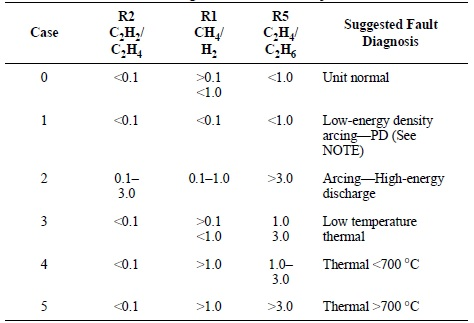)

In [ ]:
def predict_rogers(row):
    h2 = row["H2"]
    ch4 = row["CH4"]
    c2h6 = row["C2H6"]
    c2h4 = row["C2H4"]
    c2h2 = row["C2H2"]

    eps = 1e-5

    # Compute 3 basic ratios
    r1 = c2h2 / (c2h4 + eps)  # C2H2 / C2H4
    r2 = ch4 / (h2 + eps)  # CH4 / H2
    r3 = c2h4 / (c2h6 + eps)  # C2H4 / C2H6

    # Rogers classification logic
    if r1 < 0.1 and 0.1 <= r2 <= 1.0 and r3 < 1.0:
        return "NF"
    elif r1 < 0.1 and r2 < 0.1 and r3 < 1.0:
        return "PD"
    elif 0.1 <= r1 <= 1.0 and 0.1 <= r2 <= 1.0 and r3 > 3.0:
        return "D1"
    elif r1 > 1.0 and 0.1 <= r2 <= 1.0 and r3 > 3.0:
        return "D2"
    elif r1 < 0.1 and 0.1 <= r2 <= 1.0 and 1.0 <= r3 <= 3.0:
        return "T1"
    elif r1 < 0.1 and r2 > 1.0 and r3 < 1.0:
        return "T2"
    elif r1 < 0.1 and r2 > 1.0 and r3 > 3.0:
        return "T3"
    else:
        # If the combination is not covered by the standard, fallback to the closest Duval class
        if r1 > 0.5:
            return "D2"
        elif r3 > 2.0:
            return "T3"
        else:
            return "NF"


# Apply the method
df_copy["Rogers_Predict"] = df_copy.apply(predict_rogers, axis=1)

# Compute and display metrics
acc_rogers = accuracy_score(df_copy["Fail"], df_copy["Rogers_Predict"])
print(f"Overall Accuracy of Rogers Ratios Method: {acc_rogers:.2%}")
print("\nClassification Report for Rogers Ratios Method:")
print(
    classification_report(
        df_copy["Fail"], df_copy["Rogers_Predict"], zero_division=0
    )
)

Overall Accuracy of Rogers Ratios Method: 33.90%

Classification Report for Rogers Ratios Method:
              precision    recall  f1-score   support

          D1       0.04      0.01      0.02       598
          D2       0.45      0.79      0.58       770
          NF       0.11      0.07      0.08       740
          PD       0.84      0.32      0.47       351
          T1       0.38      0.07      0.11       463
          T2       0.03      0.10      0.05       349
          T3       0.64      0.63      0.64       879

    accuracy                           0.34      4150
   macro avg       0.36      0.29      0.28      4150
weighted avg       0.36      0.34      0.32      4150



#### Explanation of Rogers Ratios Method Results

The Rogers Ratios Method evaluates the condition of a power transformer based on the intersection of rigid intervals of three independent coefficients ($C_2H_2/C_2H_4$, $CH_4/H_2$, $C_2H_4/C_2H_6$).

#### Key Insights and Problems of the Method:

1. **Indeterminate Cases:** The main mathematical drawback of the Rogers method is the discrete nature of its rules. Real-world physicochemical processes in oil often fall outside the ideal "standard" ranges. As a result, a significant portion of the samples generate ratio codes for which the classical standard **does not provide a diagnostic solution**. 2. **High overheat selectivity:** The method does a good job of separating pure thermal defects into stages (`T1`, `T2`, `T3`), when the proportions of methane, ethane, and ethylene strictly follow the defect temperature increase.

#### RESULTS OF THE BASELINE MODELING STAGE:

Now, with the results of three classic engineering diagnostic methods, we can summarize the exploratory data analysis (EDA):
* **Duval Triangle (Accuracy ~47%)** — strong in detecting severe electrical defects and arcing (`D2`), but completely blind to the normal state (`NF`).
* **Key Gas Method (Accuracy ~46%)** — excellent at filtering normal conditions (`NF`) and detecting partial discharges (`PD`), but unable to diagnose intermediate defects (`D1`, `T2`).
* **Rogers' method** suffers from the problem of code ambiguity for mixed faults.

**Global conclusion:** None of the existing analytical methods developed by experts in the 20th century provides comprehensive and accurate (over 50%) classification of all transformer states simultaneously on a real unbalanced data stream. This fact fully confirms the relevance of implementing **machine learning models (CatBoost/XGBoost)**, capable of approximating continuous nonlinear boundaries between classes without information loss or "uncertain" zones.

In [ ]:
!pip install catboost

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = data.copy()
raw_gases = ['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2']



In [ ]:
data

,H2,CH4,C2H6,C2H4,C2H2,Fail,CH4_%,C2H4_%,C2H2_%
0,345.00,112.30,27.50,51.50,58.800,D1,50.449234,23.135668,26.415093
1,181.00,262.00,41.00,28.00,0.001,T1,90.344513,9.655139,0.000345
2,172.90,334.00,172.00,812.50,37.700,T3,28.204695,68.611720,3.183584
3,127.00,107.00,11.00,154.00,224.000,D2,22.061855,31.752577,46.185566
4,60.00,40.00,6.90,110.00,70.000,D2,18.181817,49.999998,31.818180
...,...,...,...,...,...,...,...,...,...
4145,10081.00,669.00,493.90,22.80,3977.000,D2,14.329164,0.488348,85.182488
4146,200.83,59.45,40.48,0.00,150.840,D2,28.270482,0.000000,71.729513
4147,121.00,14.00,3.00,29.00,74.000,D2,11.965811,24.786323,63.247858
4148,207.00,21.08,4.28,67.34,141.900,D2,9.152483,29.237581,61.609931


In [ ]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline

# Load the dataset
df = pd.read_csv(
    "/content/drive/MyDrive/Power transformer data for fault diagnosis/dga_dataset.csv",
    sep=";",
)

# Convert string columns with commas to floats
df["CH4"] = df["CH4"].str.replace(",", ".", regex=False).astype(float)
df["C2H4"] = df["C2H4"].str.replace(",", ".", regex=False).astype(float)
df["C2H2"] = df["C2H2"].str.replace(",", ".", regex=False).astype(float)
df["H2"] = df["H2"].str.replace(",", ".", regex=False).astype(float)
df["C2H6"] = df["C2H6"].str.replace(",", ".", regex=False).astype(float)

# Clean the 'Fail' column by stripping whitespace
df["Fail"] = df["Fail"].str.strip()

X = df.drop("Fail", axis=1)
y = df["Fail"]

# Gas indices
h2, ch4, c2h6, c2h4, c2h2 = 0, 1, 2, 3, 4


class DuvalTriangle(BaseEstimator, TransformerMixin):
    def __init__(self, add_duval_param=True):
        self.add_duval_param = add_duval_param

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Convert to NumPy array if a DataFrame is passed
        X_arr = np.asarray(X)

        if self.add_duval_param:
            # Added protection against division by zero (+ 1e-5)
            total_duval = X_arr[:, c2h2] + X_arr[:, c2h4] + X_arr[:, ch4] + 1e-5
            c2h2_duval = X_arr[:, c2h2] / total_duval
            c2h4_duval = X_arr[:, c2h4] / total_duval
            ch4_duval = X_arr[:, ch4] / total_duval
            return np.c_[X_arr, c2h2_duval, c2h4_duval, ch4_duval]
        else:
            return X_arr


class Rogers(BaseEstimator, TransformerMixin):
    def __init__(self, add_rogers_param=True):
        self.add_rogers_param = add_rogers_param

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_arr = np.asarray(X)

        if self.add_rogers_param:
            # The original 5 gases are still located in the first 5 columns of X_arr
            r1 = X_arr[:, c2h2] / (X_arr[:, c2h4] + 1e-5)
            r2 = X_arr[:, ch4] / (X_arr[:, h2] + 1e-5)
            r3 = X_arr[:, c2h4] / (X_arr[:, c2h6] + 1e-5)
            return np.c_[X_arr, r1, r2, r3]
        else:
            return X_arr


# Stratified split (highly recommended for imbalanced classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = CatBoostClassifier(
    loss_function="MultiClass",
    verbose=False,
    auto_class_weights="Balanced",
    random_state=42,
)

pipeline = Pipeline(
    [
        ("duval_method", DuvalTriangle()),
        ("rogers_method", Rogers()),
        ("model", model),
    ]
)

param_grid = {
    "duval_method__add_duval_param": [True, False],
    "rogers_method__add_rogers_param": [True, False],
    "model__iterations": [100, 200, 300],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__depth": [3, 4, 5],
    "model__l2_leaf_reg": [1, 3, 5],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Using 'f1_macro' as the scoring metric for multiclass classification,
# since standard accuracy can be overly optimistic due to dominant classes.
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)

print("=== STARTING HYPERPARAMETER TUNING AND CROSS-VALIDATION ===")
grid_search.fit(X_train, y_train)

print("\n=== SEARCH COMPLETED ===")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best Macro F1 score on cross-validation: {grid_search.best_score_:.4f}")

# Evaluate on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n=== FINAL RECOGNITION REPORT ON TEST SET (BEST PARAMETERS) ===")
print(classification_report(y_test, y_pred))

=== STARTING HYPERPARAMETER TUNING AND CROSS-VALIDATION ===

=== SEARCH COMPLETED ===
Best parameters: {'duval_method__add_duval_param': True, 'model__depth': 5, 'model__iterations': 300, 'model__l2_leaf_reg': 1, 'model__learning_rate': 0.2, 'rogers_method__add_rogers_param': True}
Best Macro F1 score on cross-validation: 0.8742

=== FINAL RECOGNITION REPORT ON TEST SET (BEST PARAMETERS) ===
              precision    recall  f1-score   support

          D1       0.88      0.88      0.88       120
          D2       0.92      0.94      0.93       154
          NF       0.99      0.96      0.98       148
          PD       0.89      0.91      0.90        70
          T1       0.88      0.91      0.90        92
          T2       0.84      0.80      0.82        70
          T3       0.95      0.96      0.96       176

    accuracy                           0.92       830
   macro avg       0.91      0.91      0.91       830
weighted avg       0.92      0.92      0.92       830



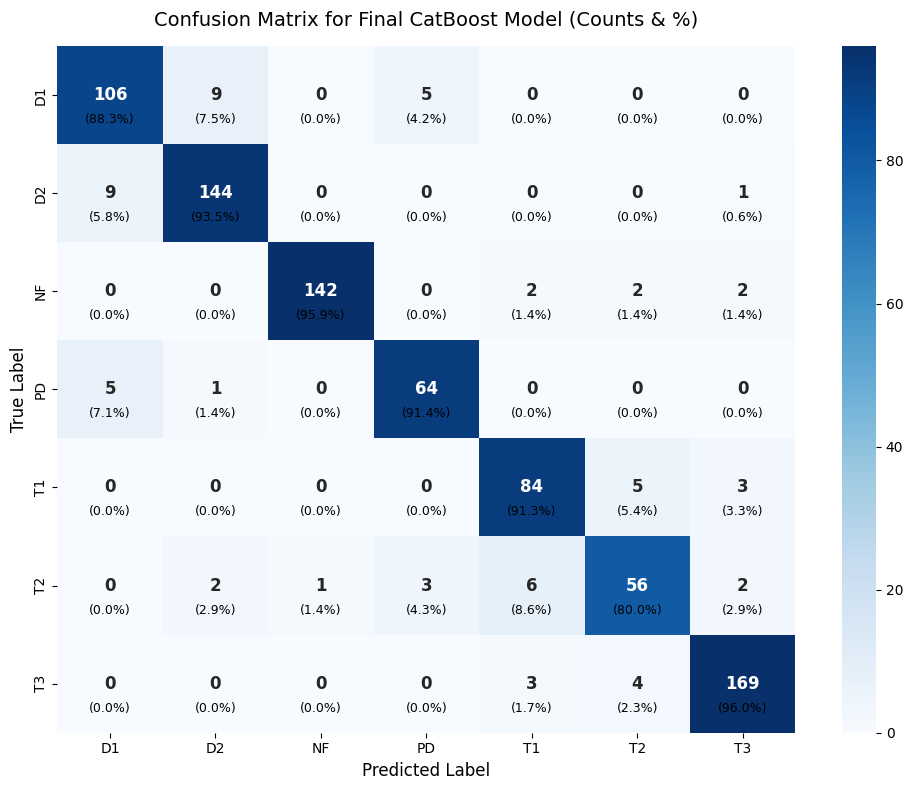

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get classes in the correct order
labels = sorted(y_test.unique())

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Convert to percentages for clarity (percentage of each class correctly predicted)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(cm_percent, annot=cm, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 12, "weight": "bold"})

# Add percentages in parentheses below the absolute numbers inside cells
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.gca().text(j + 0.5, i + 0.75, f"({cm_percent[i, j]:.1f}%)",
                       ha="center", va="center", color="black", fontsize=9)

plt.title('Confusion Matrix for Final CatBoost Model (Counts & %)', fontsize=14, pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_7212/2309202644.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




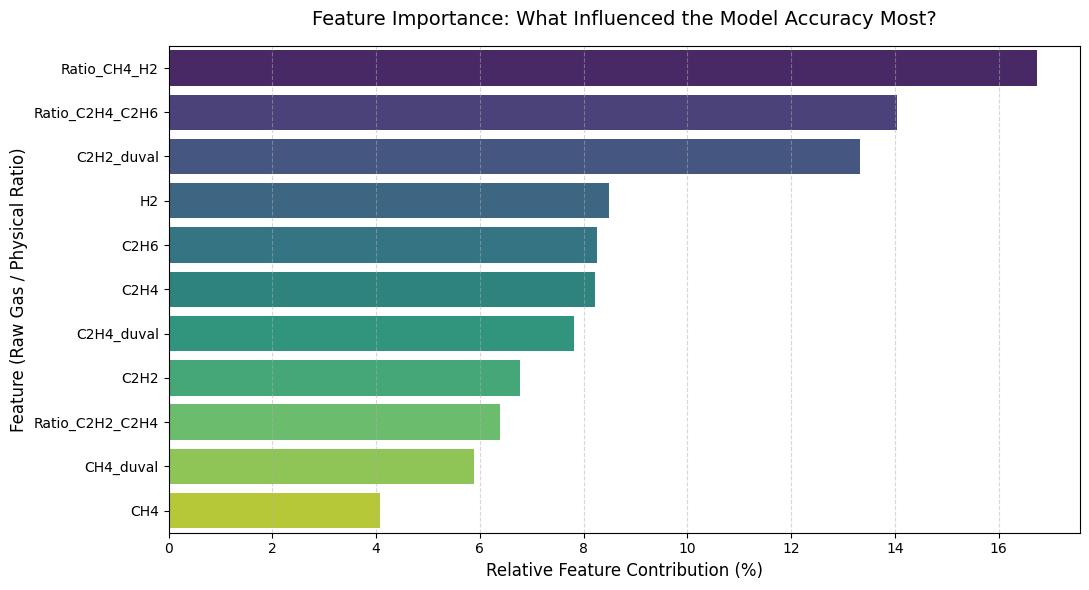

In [ ]:
# Extract the final CatBoost model from the pipeline
final_catboost = best_model.named_steps["model"]

# Get feature importances
importances = final_catboost.get_feature_importance()

# Since transformers appended columns to the original ones, let's reconstruct the exact names in the correct order
feature_names = ["H2", "CH4", "C2H6", "C2H4", "C2H2"]  # Original features
if best_model.named_steps["duval_method"].add_duval_param:
    feature_names += ["C2H2_duval", "C2H4_duval", "CH4_duval"]
if best_model.named_steps["rogers_method"].add_rogers_param:
    feature_names += ["Ratio_C2H2_C2H4", "Ratio_CH4_H2", "Ratio_C2H4_C2H6"]

# Create a DataFrame for visualization
fi_df = pd.DataFrame(
    {"Feature": feature_names, "Importance (%)": importances}
).sort_values(by="Importance (%)", ascending=False)

plt.figure(figsize=(11, 6))
sns.barplot(data=fi_df, x="Importance (%)", y="Feature", palette="viridis")
plt.title(
    "Feature Importance: What Influenced the Model Accuracy Most?",
    fontsize=14,
    pad=15,
)
plt.xlabel("Relative Feature Contribution (%)", fontsize=12)
plt.ylabel("Feature (Raw Gas / Physical Ratio)", fontsize=12)
plt.grid(True, axis="x", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()